## 1. Setup

In [ ]:
!pip install contextily

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

FIRE_CSV      = "/content/drive/MyDrive/wildfire_project/data/ca_fire_monthly_2012_2025.csv"
WEATHER_CSV   = "/content/drive/MyDrive/wildfire_project/data/california_monthly_weather.csv"
ELEVATION_CSV = "/content/drive/MyDrive/wildfire_project/data/elevation_grid.csv"
NDVI_CSV      = "/content/drive/MyDrive/wildfire_project/data/ndvi.csv"

fire      = pd.read_csv(FIRE_CSV,      parse_dates=['year_month'])
weather   = pd.read_csv(WEATHER_CSV,   parse_dates=['year_month'])
elevation = pd.read_csv(ELEVATION_CSV)
ndvi      = pd.read_csv(NDVI_CSV,      parse_dates=['time']).rename(columns={'time': 'year_month'})

print(f'Fire      : {len(fire):,} rows, {fire["year_month"].min().date()} – {fire["year_month"].max().date()}')
print(f'Weather   : {len(weather):,} rows')
print(f'Elevation : {len(elevation):,} rows')
print(f'NDVI      : {len(ndvi):,} rows')

Mounted at /content/drive


/tmp/ipykernel_507/1091238293.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ndvi      = pd.read_csv(NDVI_CSV,      parse_dates=['time']).rename(columns={'time': 'year_month'})


Fire      : 6,234,470 rows, 2012-01-01 – 2025-01-01
Weather   : 4,834,368 rows
Elevation : 39,710 rows
NDVI      : 6,194,760 rows


## 3. Peek at Each Dataset

In [28]:
print('FIRE:')
display(fire.head(3))
print()
print('WEATHER:')
display(weather.head(3))
print()
print('ELEVATION:')
display(elevation.head(3))
print()
print('NDVI:')
display(ndvi.head(3))

FIRE:


,grid_id,year_month,lat,lon,fire_occurred,burned_area_m2,month
0,000_000,2012-01-01,32.525,-124.475,0,0.0,1
1,000_000,2012-02-01,32.525,-124.475,0,0.0,2
2,000_000,2012-03-01,32.525,-124.475,0,0.0,3



WEATHER:


,grid_id,lat,lon,year_month,temp_c,precip_mm,wind_speed_ms,soil_moisture,solar_radiation
0,002_147,32.625,-117.125,2012-01-01,13.057526,0.429483,0.636054,0.099091,12764540.0
1,002_147,32.625,-117.125,2012-02-01,12.614166,1.257000,1.028083,0.116257,15247668.0
2,002_147,32.625,-117.125,2012-03-01,12.947662,1.471225,2.025865,0.125961,20139080.0



ELEVATION:


,grid_id,lat,lon,elevation_m,slope_deg,aspect_deg
0,000_000,32.525,-124.475,1063.184814,0.0,180.0
1,000_001,32.525,-124.425,1063.184814,0.0,180.0
2,000_002,32.525,-124.375,1063.184814,0.0,180.0



NDVI:


,grid_id,year_month,lat,lon,ndvi
0,000_000,2012-04-01,32.525,-124.475,NaN
1,000_001,2012-04-01,32.525,-124.425,NaN
2,000_002,2012-04-01,32.525,-124.375,NaN


## 4. Missing Values

In [4]:
def missing_summary(df, name):
    pct = df.isna().mean() * 100
    pct = pct[pct > 0]
    if pct.empty:
        print(f'{name}: no missing values ✓')
    else:
        print(f'{name}:')
        print(pct.round(2).to_string())
    print()

missing_summary(fire,      'Fire')
missing_summary(weather,   'Weather')
missing_summary(elevation, 'Elevation')
missing_summary(ndvi,      'NDVI')

Fire: no missing values ✓

Weather: no missing values ✓

Elevation: no missing values ✓

NDVI:
ndvi    57.65



## 5. Fire Occurrences Over Time
How many grid cells recorded a fire each month?

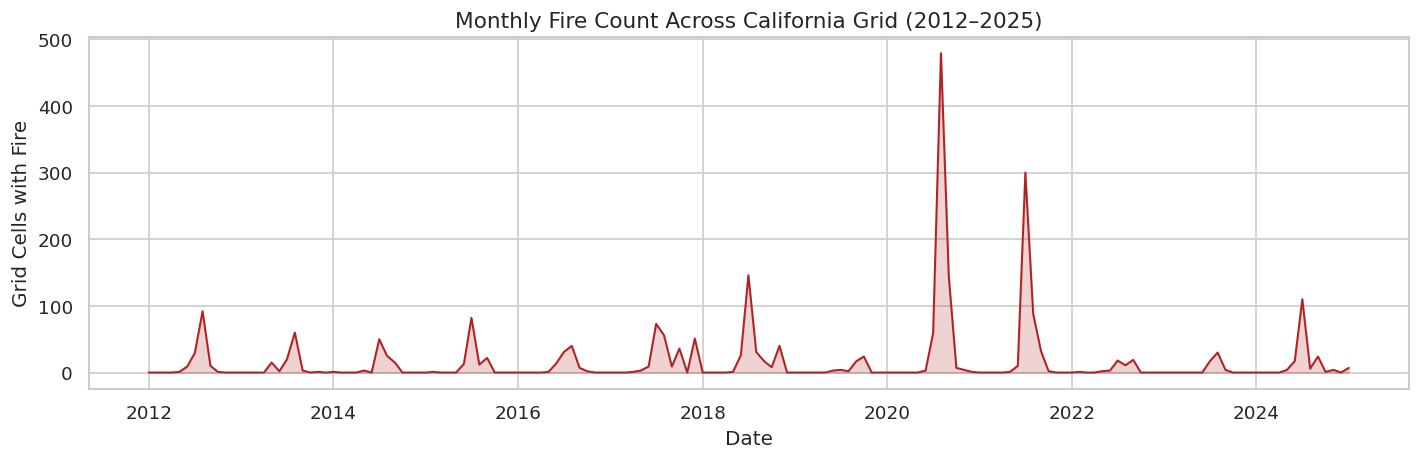

In [7]:
monthly_fires = fire.groupby('year_month')['fire_occurred'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_fires['year_month'], monthly_fires['fire_occurred'], color='firebrick', linewidth=1.2)
ax.fill_between(monthly_fires['year_month'], monthly_fires['fire_occurred'], alpha=0.2, color='firebrick')
ax.set_title('Monthly Fire Count Across California Grid (2012–2025)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Grid Cells with Fire')
plt.tight_layout()
plt.show()

## 6. Seasonality — Fires by Month
Do fires peak during the summer fire season (June–October)?

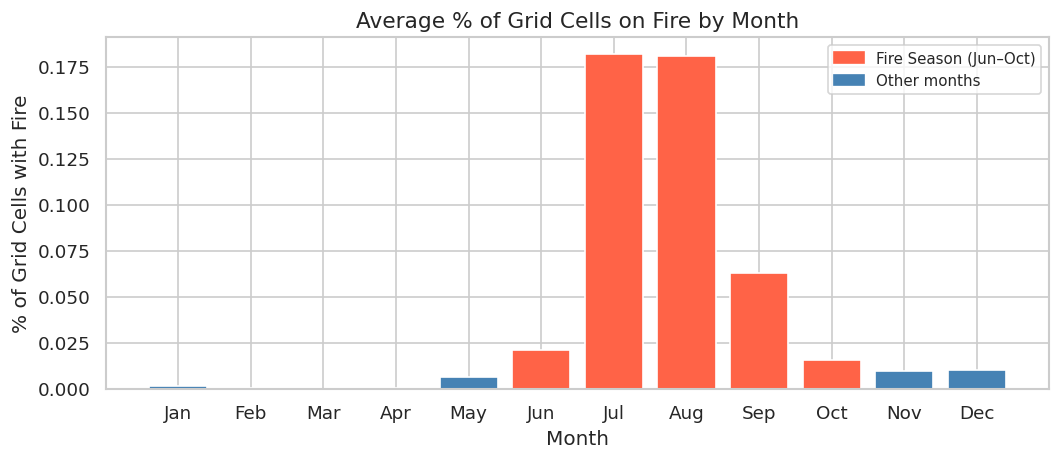

In [8]:
fire['month'] = fire['year_month'].dt.month
month_avg = fire.groupby('month')['fire_occurred'].mean() * 100

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['tomato' if m in range(6, 11) else 'steelblue' for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(month_labels, month_avg, color=colors)
ax.set_title('Average % of Grid Cells on Fire by Month', fontsize=13)
ax.set_ylabel('% of Grid Cells with Fire')
ax.set_xlabel('Month')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tomato', label='Fire Season (Jun–Oct)'),
                   Patch(color='steelblue', label='Other months')], fontsize=9)
plt.tight_layout()
plt.show()

## 7. Where Do Fires Occur? (Spatial Distribution)
A quick scatter plot of all fire events on the California grid.

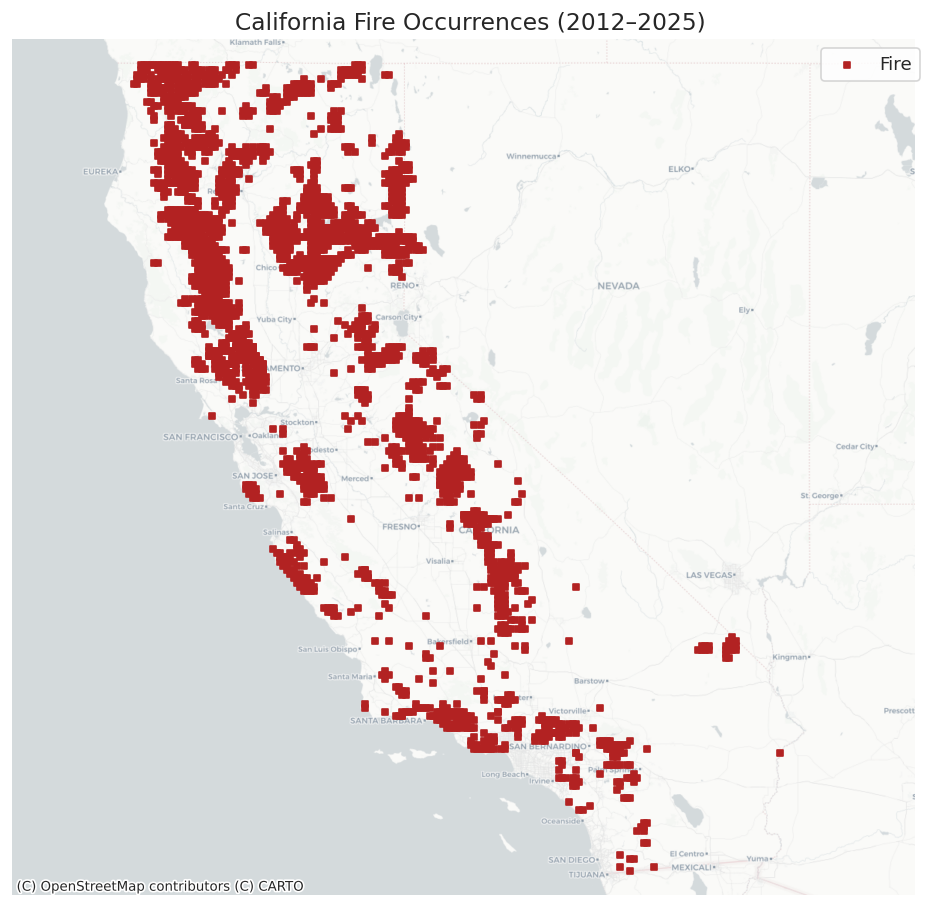

In [27]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# keep only fire occurrences
fire_pts = fire[fire["fire_occurred"] == 1]

gdf_fire = gpd.GeoDataFrame(
    fire_pts,
    geometry=gpd.points_from_xy(fire_pts["lon"], fire_pts["lat"]),
    crs="EPSG:4326"
)

# reproject to Web Mercator for contextily
gdf_fire = gdf_fire.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 10))

gdf_fire.plot(
    ax=ax,
    markersize=10,
    marker="s",
    color="firebrick",
    alpha=1,
    label="Fire"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# zoom roughly to California
ax.set_xlim(-1.4e7, -1.25e7)
ax.set_ylim(3.8e6, 5.2e6)


ax.set_title("California Fire Occurrences (2012–2025)", fontsize=14)
ax.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 8. Weather Feature Distributions
How do key weather variables differ between fire and no-fire months?

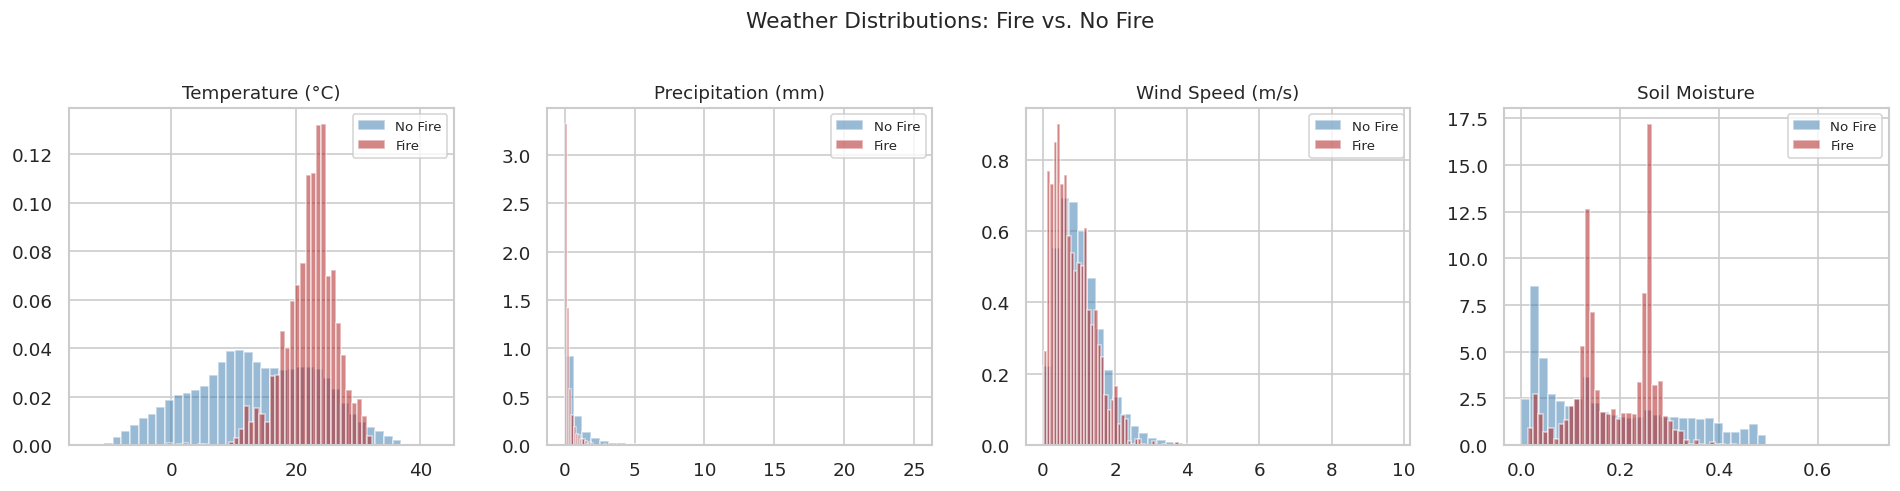

In [18]:
# Merge fire labels onto weather for comparison
weather_labeled = weather.merge(
    fire[['grid_id', 'year_month', 'fire_occurred']],
    on=['grid_id', 'year_month'], how='inner'
)

features_to_plot = ['temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture']
labels = ['Temperature (°C)', 'Precipitation (mm)', 'Wind Speed (m/s)', 'Soil Moisture']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat, label in zip(axes, features_to_plot, labels):
    for val, color, name in [(0, 'steelblue', 'No Fire'), (1, 'firebrick', 'Fire')]:
        data = weather_labeled[weather_labeled['fire_occurred'] == val][feat].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Weather Distributions: Fire vs. No Fire', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Elevation & Terrain
Do fires tend to happen at certain elevations or slopes?

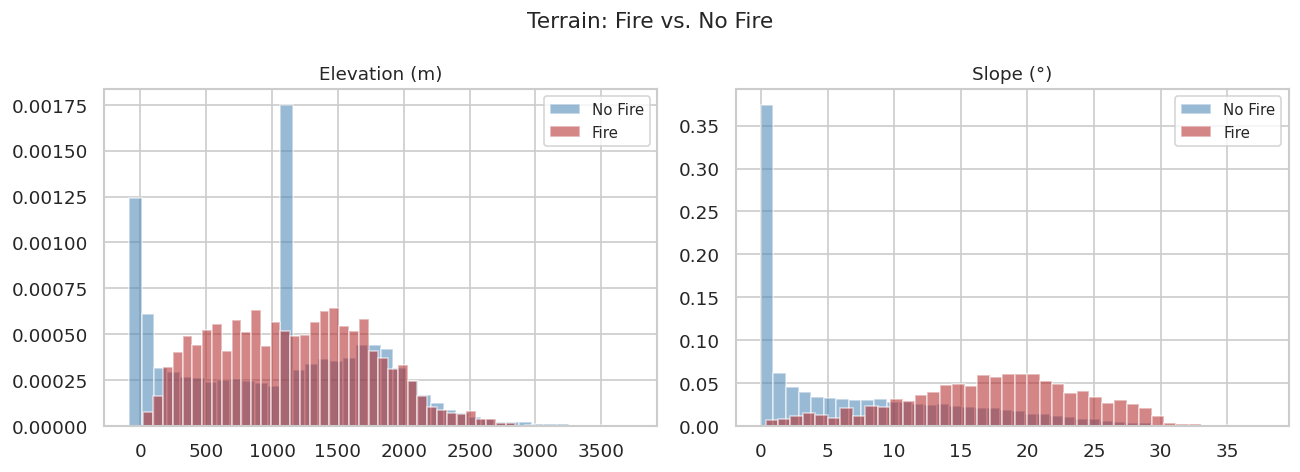

In [17]:
terrain_labeled = fire[['grid_id', 'fire_occurred']].merge(
    elevation[['grid_id', 'elevation_m', 'slope_deg']], on='grid_id', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, label in zip(axes, ['elevation_m', 'slope_deg'], ['Elevation (m)', 'Slope (°)']):
    for val, color, name in [(0, 'steelblue', 'No Fire'), (1, 'firebrick', 'Fire')]:
        data = terrain_labeled[terrain_labeled['fire_occurred'] == val][col].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle('Terrain: Fire vs. No Fire', fontsize=13)
plt.tight_layout()
plt.show()

## 10. NDVI — Vegetation Greenness
Lower NDVI = drier/more stressed vegetation = higher fire risk?

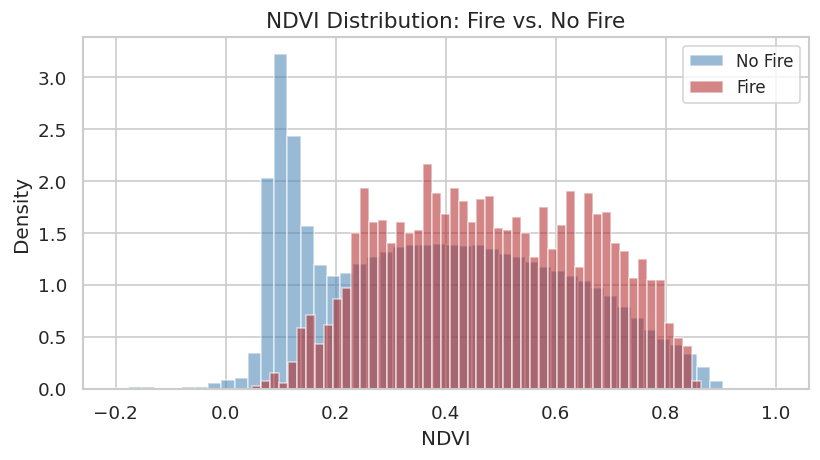

In [13]:
ndvi_labeled = ndvi.merge(
    fire[['grid_id', 'year_month', 'fire_occurred']],
    on=['grid_id', 'year_month'], how='inner'
)

fig, ax = plt.subplots(figsize=(7, 4))
for val, color, name in [(0, 'steelblue', 'No Fire'), (1, 'firebrick', 'Fire')]:
    data = ndvi_labeled[ndvi_labeled['fire_occurred'] == val]['ndvi'].dropna()
    ax.hist(data, bins=50, alpha=0.55, color=color, label=name, density=True)

ax.set_title('NDVI Distribution: Fire vs. No Fire', fontsize=13)
ax.set_xlabel('NDVI')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 11. Correlation Heatmap
How do all numeric features relate to each other (and to `fire_occurred`)?

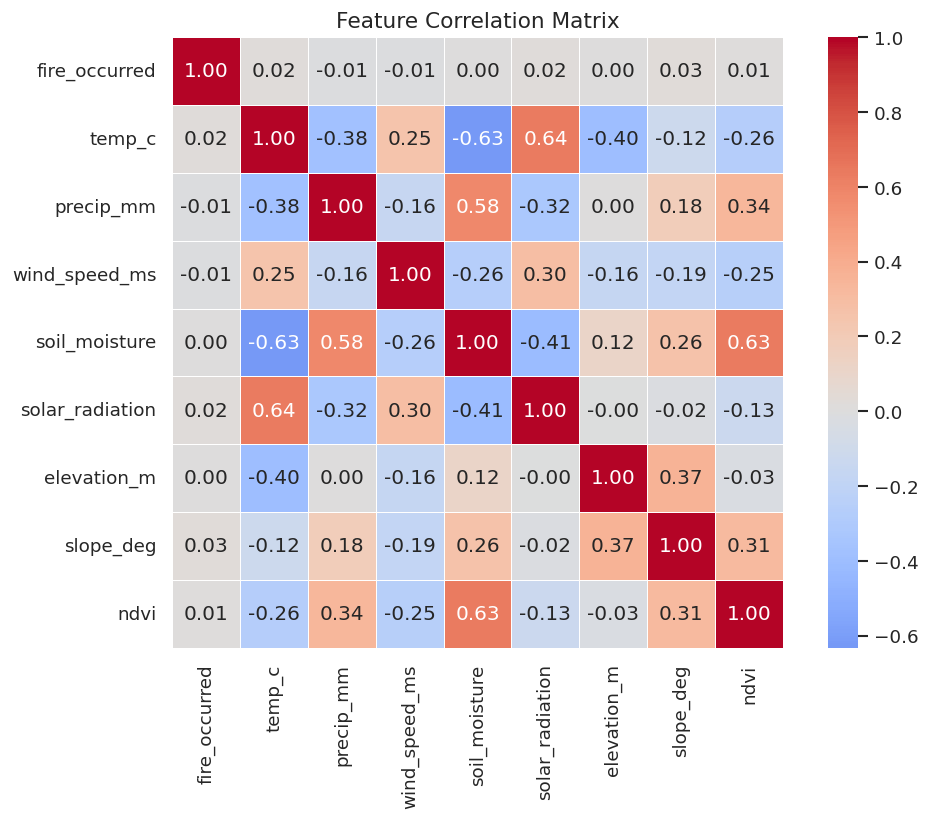

In [14]:
corr_df = fire[['grid_id', 'year_month', 'fire_occurred']].merge(
    weather[['grid_id', 'year_month', 'temp_c', 'precip_mm', 'wind_speed_ms', 'soil_moisture', 'solar_radiation']],
    on=['grid_id', 'year_month'], how='left'
).merge(
    elevation[['grid_id', 'elevation_m', 'slope_deg']], on='grid_id', how='left'
).merge(
    ndvi[['grid_id', 'year_month', 'ndvi']], on=['grid_id', 'year_month'], how='left'
)

corr_cols = ['fire_occurred', 'temp_c', 'precip_mm', 'wind_speed_ms',
             'soil_moisture', 'solar_radiation', 'elevation_m', 'slope_deg', 'ndvi']

corr = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Class Imbalance
How rare are fire events? This matters a lot for modeling.

No Fire :  6,231,943  (99.96%)
Fire    :      2,527  (0.04%)
Imbalance ratio: 2466.1:1


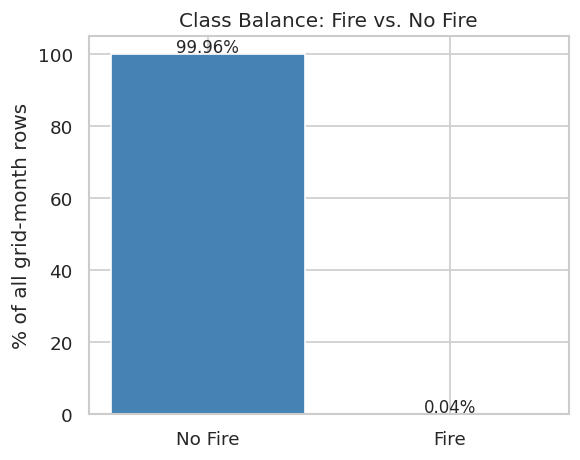

In [16]:
counts = fire['fire_occurred'].value_counts()
pct    = fire['fire_occurred'].value_counts(normalize=True) * 100

print(f'No Fire : {counts[0]:>10,}  ({pct[0]:.2f}%)')
print(f'Fire    : {counts[1]:>10,}  ({pct[1]:.2f}%)')
print(f'Imbalance ratio: {counts[0] / counts[1]:.1f}:1')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Fire', 'Fire'], [pct[0], pct[1]], color=['steelblue', 'firebrick'])
ax.set_ylabel('% of all grid-month rows')
ax.set_title('Class Balance: Fire vs. No Fire', fontsize=12)
for i, v in enumerate([pct[0], pct[1]]):
    ax.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()